# Heat Sink Shape Optimisation with Flow‑Coupled Convection

This notebook formulates and solves a **single‑objective heat‑sink optimisation problem**
using **gradient‑based optimisation**.

### Objective
Minimise the steady‑state **base temperature** of a finned heat sink by optimising
the fin height distribution.


## Finite‑difference formulation used in this notebook

The heat‑sink model is solved using a **one‑dimensional finite‑difference method (FDM)** along
the fin length. The fin is discretised into `N` control points along the vertical direction
$ x \in [0, L] $, with uniform spacing

\begin{align}
\Delta x = \frac{L}{N-1}.
\end{align}

All spatially varying quantities—fin height, cross‑sectional area, convection
coefficient, and temperatures—are represented as **arrays defined at these grid points**.

---

### Governing equation (fin)

At steady state, the fin temperature satisfies the classical fin equation with
geometry‑dependent properties:

\begin{align}
\frac{d}{dx}\left(k A(x) \frac{dT}{dx}\right)
\;-\;
h_c(x)\, P(x)\, [T(x) - T_\mathrm{air}(x)]
= 0
\end{align}

where  
- $ A(x) = w\,h(x) $ is the fin cross‑sectional area  
- $ P(x) = 2(w + h(x)) $ is the wetted perimeter  
- $ h_c(x) $ is the local convection coefficient  
- $ T_\mathrm{air}(x) $ is the local air temperature

---

### Second‑order finite‑difference discretisation

At each interior grid point $ i = 1 \ldots N-2 $, the axial conduction operator is
approximated using **second‑order central differences**:

\begin{align}
\frac{d}{dx}\left(k A \frac{dT}{dx}\right)
\;\approx\;
\frac{
k A_{i} (T_{i+1}-T_i)
-
k A_{i-1} (T_i - T_{i-1})
}{\Delta x^2}
\end{align}

This leads to a tridiagonal finite‑difference stencil:

\begin{align}
k \frac{A_{i-1}}{\Delta x^2} T_{i-1}
\;-\;
\left[
k \frac{A_{i-1}+A_i}{\Delta x^2}
+
h_{c,i} P_i
\right] T_i
\;+\;
k \frac{A_i}{\Delta x^2} T_{i+1}
=
- h_{c,i} P_i T_{\text{air},i}
\end{align}

All interior nodes contribute one linear equation to the global system

\begin{align}
\mathbf{K}\, \mathbf{T} = \mathbf{f}.
\end{align}

---

### Boundary conditions

Two physically motivated boundary conditions are enforced:

**1. Prescribed base heat flux**
at $ x = 0 $:

\begin{align}
-k A \frac{dT}{dx} = \frac{Q}{w}
\end{align}

implemented using a first‑order finite difference:

\begin{align}
k A_0 \frac{T_0 - T_1}{\Delta x} = \frac{Q \Delta x}{w}
\end{align}

**2. Adiabatic tip**
at $ x = L $:

\begin{align}
\frac{dT}{dx} = 0
\;\;\Rightarrow\;\;
T_{N-1} = T_{N-2}
\end{align}

This closes the linear system and ensures energy conservation.

---

### Air temperature coupling

Unlike classical fin theory, the surrounding air temperature is allowed to rise
axially due to convective heat pickup.

A **first‑order upwind energy balance** is used for the air stream:

\begin{align}
T_{\text{air}, i}
=
T_{\text{air}, i-1}
+
\frac{\Delta x}{\dot{m} c_p}
\,
h_{c,i-1} P_{i-1}
\,
\bigl(T_{i-1} - T_{\text{air}, i-1}\bigr)
\end{align}

This discretisation is:
- stable for positive flow direction
- consistent with forced convection physics
- computationally inexpensive

---

### Nonlinear coupling and fixed‑point iteration

The problem is **nonlinear** because:
- $ h_c(x) $ depends on fin height via airflow
- Air temperature depends on fin temperature
- Convective losses depend on both

To resolve this, a **fixed‑point (Picard) iteration** is used:

1. Guess $ T_\text{fin}(x) $, $ T_\text{air}(x) $
2. Compute convection coefficient
3. Solve the finite‑difference conduction system
4. Update air temperature via axial energy balance
5. Repeat until convergence

This approach is robust and sufficient for steady problems.

---

### Why finite differences are appropriate here

- Geometry is **1‑D and smooth**
- Design variables ($ h(x) $) are defined directly on the grid
- Leads to a **sparse linear system**
- Easily differentiable with respect to geometry
- Efficient for repeated solves during optimisation

The resulting model is fast enough to be embedded inside
a **gradient‑based optimiser** with 80 design degrees of freedom.

---

### Finite‑difference gradients in the optimisation

The objective gradient is computed using **forward finite differences**:

\begin{align}
\frac{\partial J}{\partial h_i}
\;\approx\;
\frac{J(h_i + \varepsilon) - J(h_i)}{\varepsilon}
\end{align}

Although expensive, this is acceptable for demonstration and
keeps the optimisation pipeline transparent.

## 1. Physical parameters and units

All values correspond to typical forced‑convection electronics cooling.


In [120]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import line_search
from scipy.linalg import solve
import time

# Geometry
L = 0.05          # fin length [m]
w = 0.002         # fin width [m]
s = 0.002         # fin spacing [m]
N = 80            # number of discretisation points
dx = L / (N - 1)

# Material
k = 205.0         # thermal conductivity (aluminium) [W/m/K]

# Air properties (20 C)
rho = 1.2         # [kg/m^3]
mu = 1.8e-5       # [Pa·s]
k_f = 0.026       # thermal conductivity of air [W/m/K]
Pr = 0.71

# Design bounds
h_min = 0.0001  # [m]
h_max = 0.002      # [m]
V_max = h_max * L * w * 0.3  # total fin volume [m^3]

# Temperatures
T_inf = 300.0     # ambient [K]
flux = 10e4 # W/m2
Q = flux*(s+h_max)*w          # heat input [W]

# Fan
P_fan = 0.5       # fan mechanical power [W]


## 2. Flow‑coupled convection model

The convection coefficient is computed from:
- geometry‑dependent hydraulic diameter
- fan‑power‑limited airflow

Some references for electronic cooling heat transfer coefficients:
- A. Bar‑Cohen, W. M. Rohsenow, Thermal Optimum Spacing of Vertical, Natural Convection Cooled, Parallel Plates, ASME (later extended to forced convection)
- P. Teertstra, M. M. Yovanovich, J. R. Culham, Analytical Forced Convection Modeling of Plate Fin Heat Sinks, Microelectronics Heat Transfer Laboratory, University of Waterloo
- A. Bar‑Cohen, M. Iyengar, Design and Optimization of Forced Convection Heat Sinks, Springer

In [121]:
def hydraulic_diameter(h):
    # 4 * A / P: equivalent channel diameter
    return 4. * s * h / (2. * (s + h))

def pressure_drop(U, h):
    # computed based on local velocity in channels and dependent on Reynolds number
    Dh = hydraulic_diameter(h)
    Re = rho * U * Dh / mu

    # friction factor
    f = np.where(
        Re < 2300.0,
        64.0 / Re,                 # laminar
        0.316 * Re**(-0.25)        # turbulent
    )

    dp_fric = f * (L / Dh) * 0.5 * rho * U**2

    K_minor = 1.5
    dp_minor = K_minor * 0.5 * rho * U**2

    # Return a scalar pressure drop (one flow path)
    return np.mean(dp_fric + dp_minor)

def volumetric_flow(h):
    # Estimated based on reference velocity to avoid internal root finding loop.
    A = h * s
  
    # Reference velocity (typical for electronics cooling, avoids an internal loop)
    U_ref = 2.0  # m/s

    dp_ref = pressure_drop(U_ref, h)

    U = (P_fan / (dp_ref * A))**(1.0 / 3.0) * U_ref
    return U * A

def convection_coefficient(h):
    Dh = hydraulic_diameter(h)

    # Volumetric flow rate from fan model
    Vdot = volumetric_flow(h)

    # Local channel velocity
    A_flow = s * h
    u = Vdot / A_flow

    # Reynolds and Graetz numbers
    Re = rho * u * Dh / mu
    Gz = Re * Pr * Dh / L

    # Bar–Cohen composite Nusselt number
    Nu_fd  = 7.54
    Nu_dev = 1.86 * Gz**(1/3)

    n = 2.0
    Nu = (Nu_fd**n + Nu_dev**n)**(1/n)

    # Heat transfer coefficient
    hc = Nu * k_f / Dh

    return hc

## 3. Finite‑difference heat conduction model

We solve the steady‑state fin equation with geometry‑dependent
cross‑section and convection coefficient.
``

In [122]:
def solve_fin(h, max_iter=25, tol=1e-6):
    """
    Conjugate fin–air model:
    - Fin conduction (1D)
    - Axially varying air temperature
    - Fixed-point nonlinear coupling
    """

    A = w * h
    P = 2 * (w + h)
    cp_air = 1005.0  # J/kg/K

    # Initial guesses
    T_fin = np.ones(N) * (T_inf + 10.0)
    T_air = np.ones(N) * T_inf

    # Mass flow rate (constant along fin)
    Vdot = volumetric_flow(h)
    m_dot = rho * Vdot

    for _ in range(max_iter):

        hc = convection_coefficient(h)

        # --- FIN CONDUCTION ---
        K = np.zeros((N, N))
        f = np.zeros(N)

        for i in range(1, N - 1):
            K[i, i-1] = k * A[i-1] / dx**2
            K[i, i]   = -k * (A[i-1] + A[i]) / dx**2 - hc[i] * P[i]
            K[i, i+1] = k * A[i] / dx**2
            f[i]      = -hc[i] * P[i] * T_air[i]

        # Base heat flux
        K[0, 0] = k * A[0] / dx
        K[0, 1] = -k * A[0] / dx
        f[0]    = Q * dx / w

        # Adiabatic tip
        K[-1, -1] = 1.0
        K[-1, -2] = -1.0

        T_fin_new = solve(K, f)

        # --- AIR ENERGY BALANCE WITH LOCAL MASS FLOW ---
        T_air_new = np.zeros(N)
        T_air_new[0] = T_inf
        
        A_flow = s * h
        Vdot_local = volumetric_flow(h)      
        u_local = Vdot_local / A_flow
        m_dot_local = rho * u_local * A_flow
        
        for i in range(1, N):
            q_conv = hc[i-1] * P[i-1] * (T_fin_new[i-1] - T_air_new[i-1])
        
            # local mass flow at i-1
            T_air_new[i] = (
                T_air_new[i-1]
                + dx * q_conv / (m_dot_local[i-1] * cp_air)
            )

        # Convergence check
        err = np.linalg.norm(T_fin_new - T_fin) / np.linalg.norm(T_fin)
        T_fin = T_fin_new
        T_air = T_air_new

        if err < tol:
            break

    return T_fin, T_air


## 4. Objective function

The objective is the **base temperature**, extracted from the PDE solution.
``

In [123]:
def objective(h):
    T, _ = solve_fin(h)
    return T[0]

## 5. Constraint handling

We enforce the volume constraint via projection after each descent step.
``

In [124]:
def project(h):
    h = np.clip(h, h_min, h_max)
    h[0] = h[1] # to avoid edge effects 
    h[-1] = h[-2] # to avoid edge effects 
    volume = np.sum(w * h * dx)
    if volume > V_max:
        h *= V_max / volume
    return h

## 6. Gradient computation

For clarity, we use finite differences.
The system is smooth, so this is acceptable for demonstration.

In [125]:
def gradient(h, eps=1e-6):

    g = np.zeros_like(h)
    h0 = project(h)
    f0 = objective(h0)

    for i in range(len(h)):
        hp = h.copy()
        hp[i] += eps
        hp = project(hp)
        g[i] = (objective(hp) - f0) / eps

    return g


## 7. Gradient descent with shrinking learning rate

This optimisation would be impossible using parametric studies
because the design space has 80 dimensions.

In [126]:
h = np.ones(N) * 0.005
alpha0 = 1e-5
history = []
history_h = []
history_t = []

for it in range(10000):
    t0 = time.time()
    h = project(h)
    g = gradient(h)

    alpha = alpha0 / (it + 1) # shrinking learning rate to avoid getting trapped
    h_new = project(h - alpha * g)

    h = h_new
    T_base = objective(h)
    history.append(T_base)
    history_h.append(h)
    t1 = time.time() - t0
    history_t.append(t1)

    if it > 2 and abs(history[-1] - history[-2]) < 1e-2:
        print("Converged (objective flat)")
        break

    print(f"Iter {it:02d} | Base T = {T_base:.2f} K | time = {t1:.3f} s")
avg_t = np.average(history_t)

Iter 00 | Base T = 317.67 K | time = 0.330 s
Iter 01 | Base T = 317.24 K | time = 0.961 s
Iter 02 | Base T = 315.51 K | time = 0.397 s
Iter 03 | Base T = 315.68 K | time = 0.692 s
Iter 04 | Base T = 314.49 K | time = 0.342 s
Iter 05 | Base T = 314.37 K | time = 0.392 s
Iter 06 | Base T = 314.50 K | time = 0.337 s
Iter 07 | Base T = 314.33 K | time = 0.392 s
Iter 08 | Base T = 314.41 K | time = 0.342 s
Iter 09 | Base T = 314.23 K | time = 0.385 s
Iter 10 | Base T = 314.34 K | time = 0.352 s
Iter 11 | Base T = 314.22 K | time = 0.387 s
Iter 12 | Base T = 314.30 K | time = 0.336 s
Iter 13 | Base T = 314.19 K | time = 0.366 s
Iter 14 | Base T = 314.27 K | time = 0.361 s
Iter 15 | Base T = 314.19 K | time = 0.371 s
Iter 16 | Base T = 314.26 K | time = 0.338 s
Iter 17 | Base T = 314.18 K | time = 0.396 s
Iter 18 | Base T = 314.24 K | time = 0.343 s
Iter 19 | Base T = 314.17 K | time = 0.362 s
Iter 20 | Base T = 314.23 K | time = 0.369 s
Iter 21 | Base T = 314.17 K | time = 0.368 s
Iter 22 | 

## 8. Results

We observe convergence to a non‑trivial fin shape where:
- Increasing fin size further would reduce airflow
- Smaller fins would lack surface area

This confirms the existence of a true optimum.


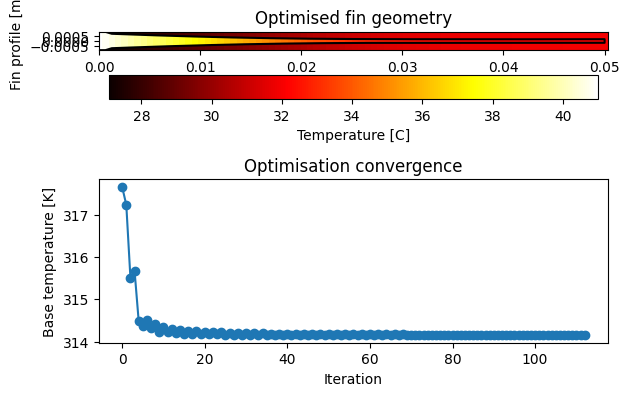

In [127]:
x = np.linspace(0, L, N)

plt.figure()
plt.subplot(2,1,1, aspect='equal')
xs, hs = np.hstack([x, x[::-1]]), np.hstack([h/2., -h[::-1]/2.])
plt.plot(xs, hs, color='k')
T, T_air = solve_fin(h)
y = np.linspace(-np.amax(h/2.), np.amax(h/2.), N)
X, Y = np.meshgrid(x, y)
# Broadcast temperature along thickness
T_field = np.tile(T-273.15, (len(y), 1))
T_air_field = np.tile(T_air-273.15, (len(y), 1))
h_interp = np.interp(X, x, h/2.)
mask = np.abs(Y) > h/2.
T_field[mask] = T_air_field[mask]
T_field = np.ma.array(T_field)

pcm = plt.pcolormesh(X, Y, T_field, shading='auto', cmap='hot')
plt.colorbar(pcm, label='Temperature [C]', orientation='horizontal')

plt.xlim(xmin=0)
plt.xlabel("Fin length [m]")
plt.ylabel("Fin profile [m]")
plt.title("Optimised fin geometry")

plt.subplot(2,1,2)
plt.plot(history, '-o')
plt.xlabel("Iteration")
plt.ylabel("Base temperature [K]")
plt.title("Optimisation convergence")

plt.tight_layout()
plt.show()

## 9. Why parametric optimisation fails

With 80 design variables, even only 2 heights per variable would require a total parametric study time of:

\begin{align}
t = 2^{80} \times t_{eval}
\end{align}

In [128]:
print('t_eval = %.3f s' % avg_t)
print ('t_opt = %.3f s' % np.sum(history_t))
print('t_param = %.0f years' % (2**80*avg_t/(3600*24*365.)))

t_eval = 0.376 s
t_opt = 42.511 s
t_param = 14421538534723578 years


Iter 00 | a=0.199 b=0.162 | T=316.33 K | dt=0.016s
Iter 01 | a=0.247 b=0.191 | T=316.20 K | dt=0.018s
Iter 02 | a=0.278 b=0.208 | T=316.13 K | dt=0.020s
Iter 03 | a=0.300 b=0.221 | T=316.08 K | dt=0.016s
Iter 04 | a=0.317 b=0.230 | T=316.04 K | dt=0.016s
Iter 05 | a=0.330 b=0.237 | T=316.02 K | dt=0.018s
Iter 06 | a=0.341 b=0.243 | T=315.99 K | dt=0.015s
Iter 07 | a=0.351 b=0.248 | T=315.98 K | dt=0.021s
Iter 08 | a=0.359 b=0.252 | T=315.96 K | dt=0.017s
Iter 09 | a=0.367 b=0.255 | T=315.95 K | dt=0.016s
Iter 10 | a=0.373 b=0.258 | T=315.94 K | dt=0.018s
Iter 11 | a=0.379 b=0.260 | T=315.93 K | dt=0.016s
Converged (quad‑quartic)
Parameterised optimisation finished.


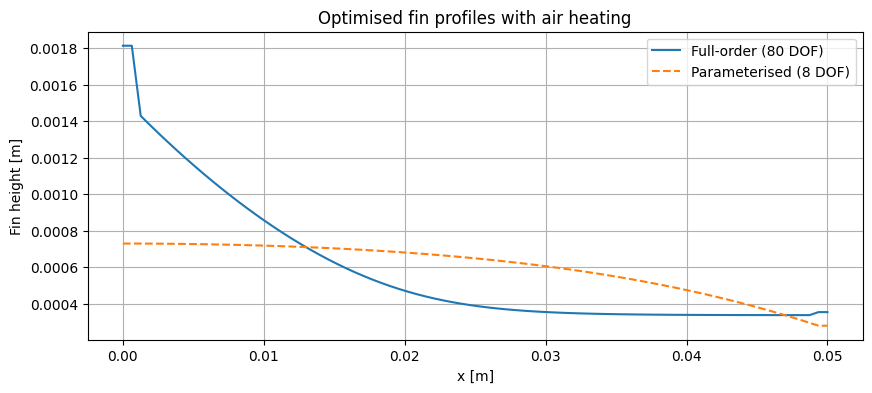

In [129]:
## 9. Reduced parameterisation

def quad_quartic_fin(a, b):
    """
    Quadratic–quartic fin with exact volume constraint:
    h(x) = h0 * (1 - a (x/L)^2 - b (x/L)^4)
    """

    # Physically admissible bounds
    a = np.clip(a, 0.0, 0.9)
    b = np.clip(b, 0.0, 0.9)

    denom = 1.0 - a / 3.0 - b / 5.0
    if denom <= 0:
        denom = 1e-6  # safety

    # Exact volume enforcement
    h0 = V_max / (w * L * denom)

    xi = x / L
    shape = 1.0 - a * xi ** 2 - b * xi ** 4
    shape = np.maximum(shape, 0.05)  # avoid tip collapse

    h = h0 * shape
    h = np.clip(h, h_min, h_max)

    h[0] = h[1]
    h[-1] = h[-2]

    return h


def objective_param(ab):
    a, b = ab
    return objective(quad_quartic_fin(a, b))


ab = np.array([0.1, 0.1])  # initial guess (now matters!)
alpha0 = 5e-2

history_param = []
history_h_param = []

for it in range(100):
    t0 = time.time()
    f0 = objective_param(ab)

    g = np.zeros(2)
    eps = 1e-4

    for i in range(2):
        abp = ab.copy()
        abp[i] += eps
        g[i] = (objective_param(abp) - f0) / eps

    alpha = alpha0 / (it + 1)
    ab = ab - alpha * g

    # Parameter bounds
    ab[0] = np.clip(ab[0], 0.0, 0.9)
    ab[1] = np.clip(ab[1], 0.0, 0.9)

    T_base = objective_param(ab)
    history_param.append(T_base)
    history_h_param.append(quad_quartic_fin(ab[0], ab[1]))

    dt = time.time() - t0
    print(f"Iter {it:02d} | a={ab[0]:.3f} b={ab[1]:.3f} | T={T_base:.2f} K | dt={dt:.3f}s")

    if it > 2 and abs(history_param[-1] - history_param[-2]) < 1e-2:
        print("Converged (quad‑quartic)")
        break

h_param = quad_quartic_fin(*ab)
print("Parameterised optimisation finished.")
plt.figure(figsize=(10, 4))
plt.plot(x, h, label="Full‑order (80 DOF)")
plt.plot(x, h_param, "--", label="Parameterised (8 DOF)")
#plt.plot(x, h_surr, ":", label="Surrogate")
plt.xlabel("x [m]")
plt.ylabel("Fin height [m]")
plt.legend()
plt.grid(True)
plt.title("Optimised fin profiles with air heating")
plt.show()


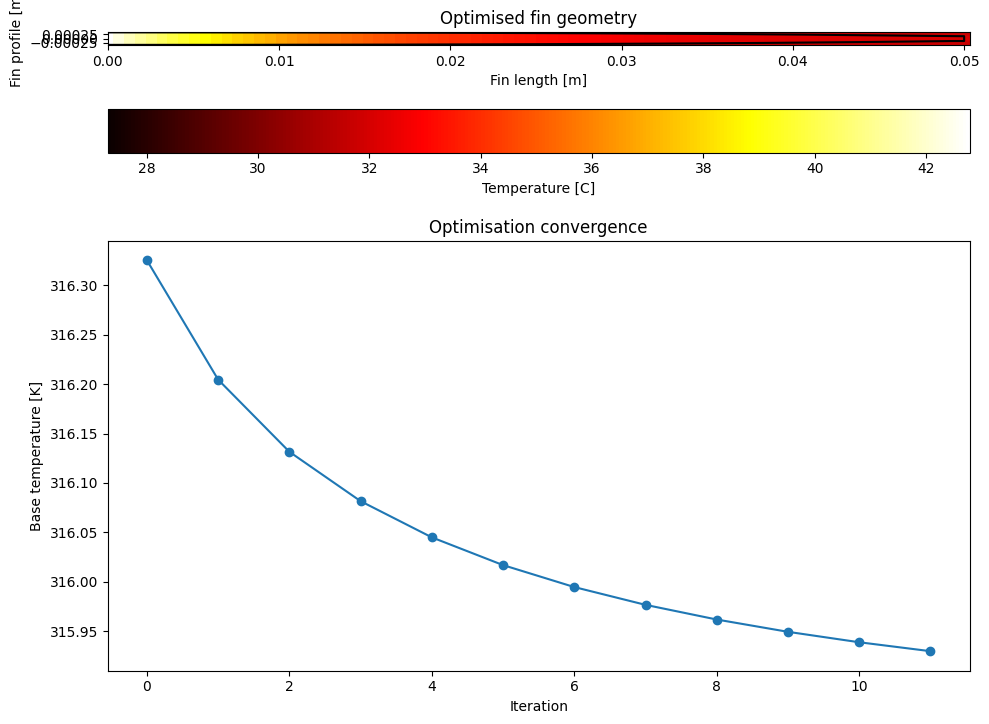

In [130]:
x = np.linspace(0, L, N)
h = h_param
plt.figure(figsize=(10,10))
plt.subplot(2, 1, 1, aspect='equal')
xs, hs = np.hstack([x, x[::-1]]), np.hstack([h_param / 2., -h_param[::-1] / 2.])
plt.plot(xs, hs, color='k')
T,T_air = solve_fin(h_param)
y = np.linspace(-np.amax(h_param / 2.), np.amax(h_param / 2.), N)
X, Y = np.meshgrid(x, y)
# Broadcast temperature along thickness
T_field = np.tile(T-273.15, (len(y), 1))
T_field_air = np.tile(T_air-273.15, (len(y), 1))
h_interp = np.interp(X, x, h/2.)
mask = np.abs(Y) > h/2.
T_field[mask] = T_field_air[mask]
pcm = plt.pcolormesh(X, Y, T_field, shading='auto', cmap='hot')
plt.colorbar(pcm, label='Temperature [C]', orientation='horizontal')

plt.xlim(xmin=0)
plt.xlabel("Fin length [m]")
plt.ylabel("Fin profile [m]")
plt.title("Optimised fin geometry")

plt.subplot(2, 1, 2)
plt.plot(history_param, '-o')
plt.xlabel("Iteration")
plt.ylabel("Base temperature [K]")
plt.title("Optimisation convergence")

plt.tight_layout()
plt.show()